In [ ]:
!pip install git+https://github.com/huggingface/transformers.git


In [ ]:
!pip install accelerate safetensors


In [1]:
import os          # File‑system helpers (paths, env vars, etc.)
import random      
import textwrap    # Nicely format long strings for display
import io          # In‑memory byte streams (e.g. image buffers)
import requests    
import numpy as np  

# ── Deep‑learning stack ─────────────────────────────────────────
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoProcessor, AutoModelForVision2Seq

import torch

# ── Imaging & visualisation ─────────────────────────────────────
from PIL import Image                    
import matplotlib.pyplot as plt          
import matplotlib.patches as patches     

         

2025-09-04 18:31:41.793339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757010702.186396      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757010702.307582      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModelForVision2Seq.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
print(f"Model loaded on: {model.device}")

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded on: cuda:0


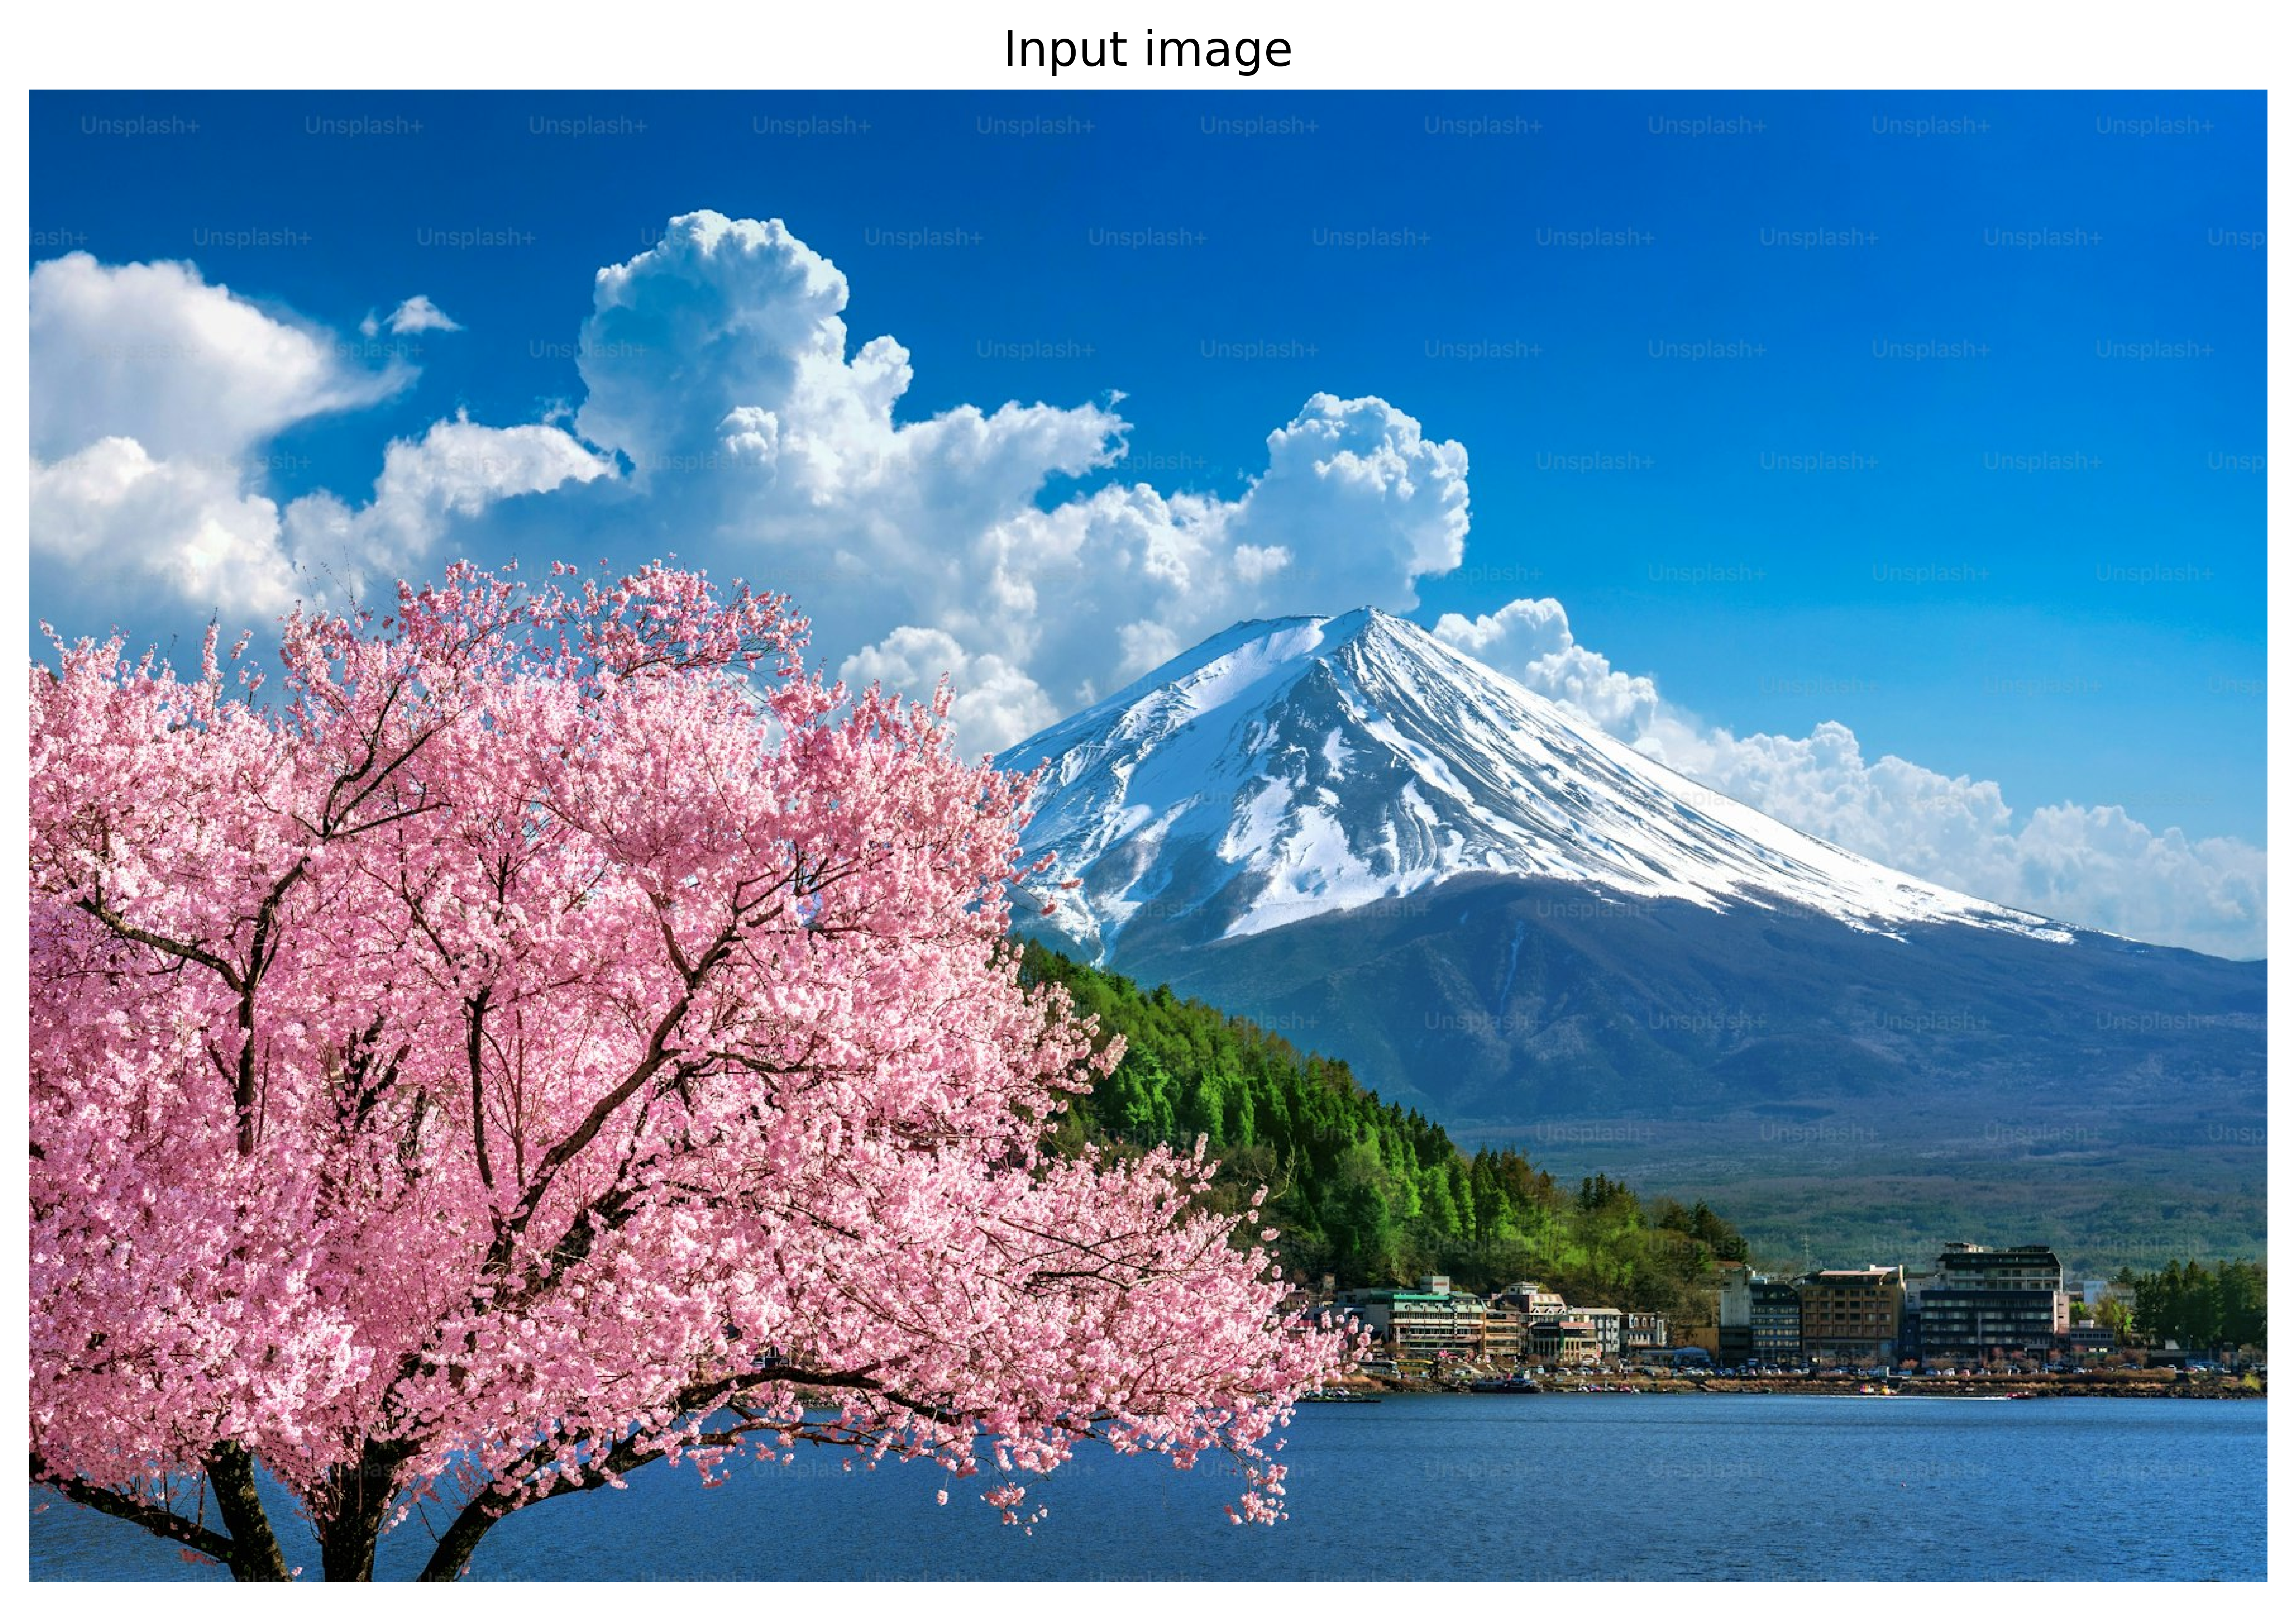

In [4]:
url = "https://plus.unsplash.com/premium_photo-1661964177687-57387c2cbd14?q=80&w=1770&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
img = Image.open(io.BytesIO(requests.get(url, timeout=15).content)).convert("RGB")

# Display the image
plt.figure(figsize=(10,8),dpi=800)
plt.imshow(img)
plt.axis("off")
plt.title("Input image")
plt.show()

In [5]:
msgs = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Describe this image."}
        ],
    }
]

In [6]:
text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)



In [7]:
inputs = processor(text=text_prompt, images=img, return_tensors="pt").to(model.device)

# Generate
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=50)

print(processor.decode(outputs[0], skip_special_tokens=True))

OutOfMemoryError: CUDA out of memory. Tried to allocate 6.68 GiB. GPU 0 has a total capacity of 14.74 GiB of which 6.66 GiB is free. Process 4470 has 8.08 GiB memory in use. Of the allocated memory 7.90 GiB is allocated by PyTorch, and 55.86 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Extract the newly generated tokens (skip the prompt length)
caption = processor.batch_decode(
    generated_ids[:, inputs.input_ids.shape[-1]:],
    skip_special_tokens=True
)[0]

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()

# Print caption
width = 80
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption)